In [ ]:
# 1. ACTUALIZAR LIBRERÍAS
!pip install --upgrade kaggle -q
!pip install split-folders -q

import os
import shutil
import splitfolders

# 2. Configurar la API de Kaggle
os.environ['KAGGLE_API_TOKEN'] = "KGAT_da83aa18869cd053269946e467fa0b7c"

# Limpieza inicial de carpetas viejas para no mezclar
if os.path.exists('/content/raw_data'): shutil.rmtree('/content/raw_data')
if os.path.exists('/content/dataset'): shutil.rmtree('/content/dataset')

# 3. Descargar el dataset
print("Descargando dataset desde Kaggle...")
!kaggle datasets download -d noamaanabdulazeem/jmuben-coffee-dataset

# 4. Descomprimir
print("Descomprimiendo archivos...")
!unzip -o -q jmuben-coffee-dataset.zip -d /content/raw_data

# 5. --- FUSIONAR CARPETAS DUPLICADAS (PASO CRÍTICO) ---
# La carpeta donde Kaggle extrae todo es /content/raw_data/JMuBEN
ruta_base = '/content/raw_data/JMuBEN'

def fusionar_carpetas(origen, destino):
    path_orig = os.path.join(ruta_base, origen)
    path_dest = os.path.join(ruta_base, destino)
    if os.path.exists(path_orig):
        print(f"Fusionando {origen} en {destino}...")
        os.makedirs(path_dest, exist_ok=True)
        for archivo in os.listdir(path_orig):
            shutil.move(os.path.join(path_orig, archivo), os.path.join(path_dest, archivo))
        os.rmdir(path_orig)

# Corregimos los nombres duplicados
fusionar_carpetas('Cerscospora', 'Cercospora')
fusionar_carpetas('Leaf rust', 'Rust')

print(f"\n[*] Carpetas finales detectadas: {os.listdir(ruta_base)}")

# 6. Dividir las imágenes en Train, Val y Test
print("Organizando carpetas y dividiendo en Train (70%), Val (15%) y Test (15%)...")
splitfolders.ratio(ruta_base, output="/content/dataset", seed=42, ratio=(0.7, 0.15, 0.15))

print("\n=======================================================")
print("¡ÉXITO! Ahora tienes exactamente 5 clases limpias.")
print("Ya puedes volver a la celda de los modelos y darle PLAY.")
print("=======================================================")

Descargando dataset desde Kaggle...
Dataset URL: https://www.kaggle.com/datasets/noamaanabdulazeem/jmuben-coffee-dataset
License(s): unknown
jmuben-coffee-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Descomprimiendo archivos...
Fusionando Cerscospora en Cercospora...
Fusionando Leaf rust en Rust...

[*] Carpetas finales detectadas: ['Healthy', 'Phoma', 'Miner', 'Rust', 'Cercospora']
Organizando carpetas y dividiendo en Train (70%), Val (15%) y Test (15%)...


Copying files: 58549 files [00:17, 3381.35 files/s]


¡ÉXITO! Ahora tienes exactamente 5 clases limpias.
Ya puedes volver a la celda de los modelos y darle PLAY.


[*] Dispositivo configurado: cuda
[*] GPU detectada: Tesla T4

[*] Dataset REAL cargado con éxito desde /content/dataset
[*] Clases detectadas (5): ['Cercospora', 'Healthy', 'Miner', 'Phoma', 'Rust']

1. MODELO 0: BASELINE CNN
Epoch 1/5 | Train Loss: 0.2460 Acc: 0.9210 | Val Loss: 0.0302 Acc: 0.9916
Epoch 2/5 | Train Loss: 0.0863 Acc: 0.9756 | Val Loss: 0.0132 Acc: 0.9961
Epoch 3/5 | Train Loss: 0.0683 Acc: 0.9818 | Val Loss: 0.0601 Acc: 0.9835
Epoch 4/5 | Train Loss: 0.0629 Acc: 0.9837 | Val Loss: 0.0671 Acc: 0.9867
Epoch 5/5 | Train Loss: 0.0492 Acc: 0.9880 | Val Loss: 0.0034 Acc: 0.9992
[*] Entrenamiento completado en 16m 6s


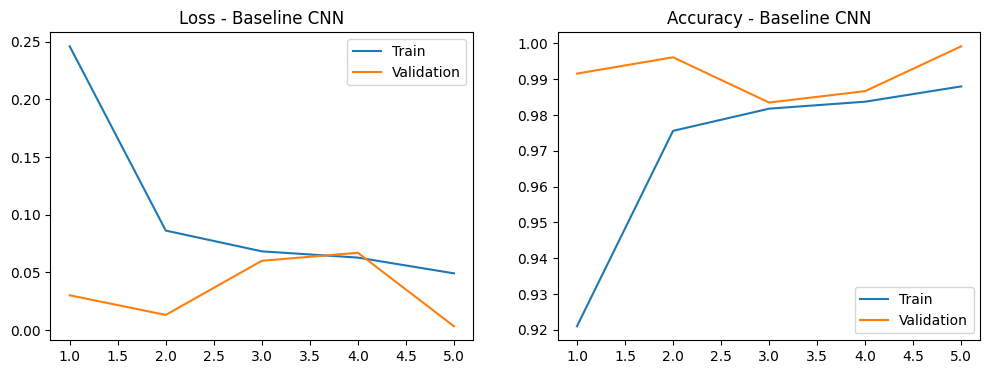


--- REPORTE FINAL: Baseline CNN ---
              precision    recall  f1-score   support

  Cercospora       1.00      1.00      1.00      1153
     Healthy       1.00      1.00      1.00      2848
       Miner       1.00      1.00      1.00      2548
       Phoma       1.00      1.00      1.00       987
        Rust       1.00      0.99      1.00      1251

    accuracy                           1.00      8787
   macro avg       1.00      1.00      1.00      8787
weighted avg       1.00      1.00      1.00      8787



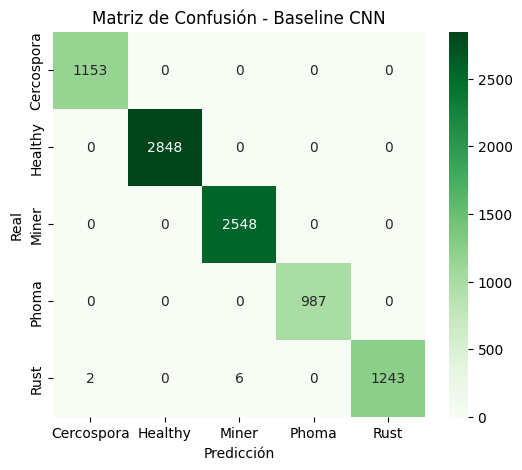


2. MODELO 1: EFFICIENTNET-B0
Epoch 1/5 | Train Loss: 0.1724 Acc: 0.9554 | Val Loss: 0.0683 Acc: 0.9794
Epoch 2/5 | Train Loss: 0.0747 Acc: 0.9783 | Val Loss: 0.0423 Acc: 0.9885
Epoch 3/5 | Train Loss: 0.0647 Acc: 0.9806 | Val Loss: 0.0343 Acc: 0.9942
Epoch 4/5 | Train Loss: 0.0596 Acc: 0.9809 | Val Loss: 0.0215 Acc: 0.9936
Epoch 5/5 | Train Loss: 0.0570 Acc: 0.9817 | Val Loss: 0.0151 Acc: 0.9953
[*] Entrenamiento completado en 15m 25s


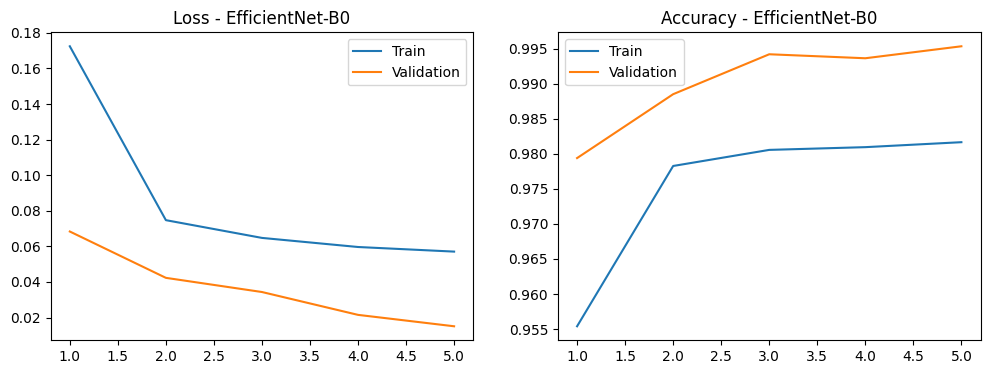


--- REPORTE FINAL: EfficientNet-B0 ---
              precision    recall  f1-score   support

  Cercospora       0.99      1.00      1.00      1153
     Healthy       1.00      1.00      1.00      2848
       Miner       0.99      1.00      1.00      2548
       Phoma       0.99      0.99      0.99       987
        Rust       1.00      0.99      1.00      1251

    accuracy                           1.00      8787
   macro avg       1.00      1.00      1.00      8787
weighted avg       1.00      1.00      1.00      8787



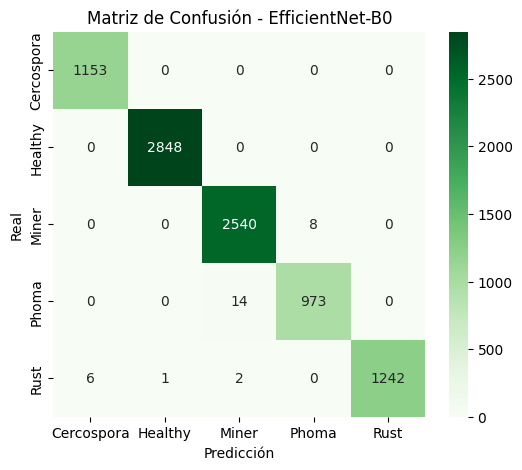


3. MODELO 2: MOBILENET V3 SMALL
Epoch 1/5 | Train Loss: 0.1211 Acc: 0.9723 | Val Loss: 0.0481 Acc: 0.9826
Epoch 2/5 | Train Loss: 0.0433 Acc: 0.9886 | Val Loss: 0.0323 Acc: 0.9897
Epoch 3/5 | Train Loss: 0.0340 Acc: 0.9900 | Val Loss: 0.0258 Acc: 0.9921
Epoch 4/5 | Train Loss: 0.0304 Acc: 0.9909 | Val Loss: 0.0207 Acc: 0.9929
Epoch 5/5 | Train Loss: 0.0292 Acc: 0.9911 | Val Loss: 0.0224 Acc: 0.9933
[*] Entrenamiento completado en 14m 35s


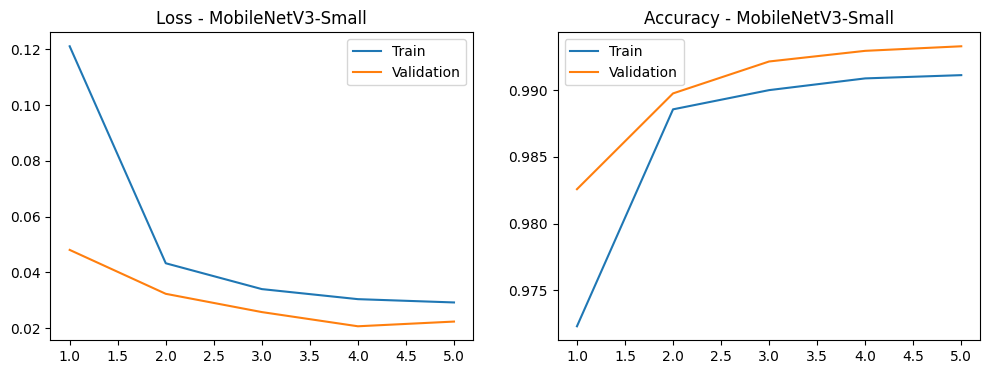


--- REPORTE FINAL: MobileNetV3-Small ---
              precision    recall  f1-score   support

  Cercospora       0.98      1.00      0.99      1153
     Healthy       1.00      1.00      1.00      2848
       Miner       0.99      0.99      0.99      2548
       Phoma       0.98      0.99      0.99       987
        Rust       1.00      0.98      0.99      1251

    accuracy                           0.99      8787
   macro avg       0.99      0.99      0.99      8787
weighted avg       0.99      0.99      0.99      8787



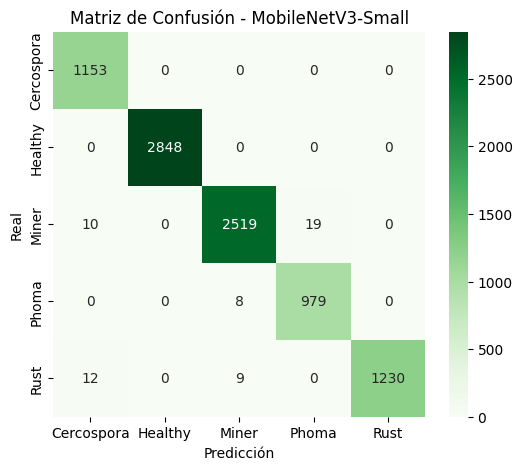


[*] PIPELINE FINALIZADO EXITOSAMENTE.


In [ ]:
# ==============================================================================
# PROJECT 2: IMAGE MODEL USING DEEP LEARNING
# Team: Luis Alejandro Gil, Santiago Acosta, Sergio Andres Botia
# Dataset: JMuBEN (Coffee Leaf Diseases) - REAL DATA VERSION
# ==============================================================================

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. CONFIGURACIÓN DEL DISPOSITIVO
# ==============================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Dispositivo configurado: {device}")
if torch.cuda.is_available():
    print(f"[*] GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("[!] ADVERTENCIA: No se detectó GPU. El entrenamiento será muy lento.")

# ==============================================================================
# 2. PREPARACIÓN DEL DATASET Y DATA AUGMENTATION
# ==============================================================================
IMG_SIZE = 224
BATCH_SIZE = 32

# Data Augmentation para entrenamiento (Simulación de condiciones de campo)
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para validación y prueba
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# DEFINICIÓN DE RUTAS REALES
dataset_dir = '/content/dataset'

train_dir = os.path.join(dataset_dir, 'train')
val_dir   = os.path.join(dataset_dir, 'val')
test_dir  = os.path.join(dataset_dir, 'test')

# Cargar datasets reales (Lanzará error si no se ha ejecutado la celda de Kaggle)
try:
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
    val_dataset   = datasets.ImageFolder(val_dir, transform=test_transforms)
    test_dataset  = datasets.ImageFolder(test_dir, transform=test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    class_names = train_dataset.classes
    num_classes = len(class_names)
    print(f"\n[*] Dataset REAL cargado con éxito desde {dataset_dir}")
    print(f"[*] Clases detectadas ({num_classes}): {class_names}")
except Exception as e:
    print(f"\n[!] ERROR CRÍTICO: No se encontró el dataset en {dataset_dir}.")
    print("[!] Asegúrate de ejecutar primero la celda de descarga de Kaggle.")
    raise e

# ==============================================================================
# 3. DEFINICIÓN DE LAS 3 ARQUITECTURAS
# ==============================================================================

# MODELO 0: Baseline CNN (Desde cero)
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# MODELO 1: EfficientNet-B0 (Transfer Learning)
def get_efficientnet(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

# MODELO 2: MobileNetV3-Small (Transfer Learning)
def get_mobilenet(num_classes):
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    return model

# ==============================================================================
# 4. FUNCIÓN DE ENTRENAMIENTO (Model Fitting)
# ==============================================================================
def train_model(model, criterion, optimizer, num_epochs=5):
    model = model.to(device)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_acc'].append(val_acc.item())

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    time_elapsed = time.time() - start_time
    print(f'[*] Entrenamiento completado en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

# ==============================================================================
# 5. FUNCIONES DE EVALUACIÓN
# ==============================================================================
def evaluate_and_plot(model, history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Validation')
    plt.title(f'Loss - {model_name}')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train')
    plt.plot(epochs, history['val_acc'], label='Validation')
    plt.title(f'Accuracy - {model_name}')
    plt.legend()
    plt.show()

    model.eval()
    all_preds, all_labels = [],[]
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n--- REPORTE FINAL: {model_name} ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.show()

# ==============================================================================
# 6. EJECUCIÓN DEL PIPELINE
# ==============================================================================
# Ajuste de pesos por desbalance (Phoma y Cercospora suelen ser menos comunes)
class_weights = torch.tensor([1.5, 1.0, 1.2, 1.3, 1.1]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
EPOCHS = 5

print("\n" + "="*50)
print("1. MODELO 0: BASELINE CNN")
model_0 = BaselineCNN(num_classes)
optimizer_0 = optim.Adam(model_0.parameters(), lr=0.001)
trained_m0, hist_m0 = train_model(model_0, criterion, optimizer_0, num_epochs=EPOCHS)
evaluate_and_plot(trained_m0, hist_m0, "Baseline CNN")

print("\n" + "="*50)
print("2. MODELO 1: EFFICIENTNET-B0")
model_1 = get_efficientnet(num_classes)
optimizer_1 = optim.Adam(model_1.classifier.parameters(), lr=0.001)
trained_m1, hist_m1 = train_model(model_1, criterion, optimizer_1, num_epochs=EPOCHS)
evaluate_and_plot(trained_m1, hist_m1, "EfficientNet-B0")

print("\n" + "="*50)
print("3. MODELO 2: MOBILENET V3 SMALL")
model_2 = get_mobilenet(num_classes)
optimizer_2 = optim.Adam(model_2.classifier.parameters(), lr=0.001)
trained_m2, hist_m2 = train_model(model_2, criterion, optimizer_2, num_epochs=EPOCHS)
evaluate_and_plot(trained_m2, hist_m2, "MobileNetV3-Small")

print("\n[*] PIPELINE FINALIZADO EXITOSAMENTE.")

[*] Mostrando resultados para: MOBILENET V3 SMALL


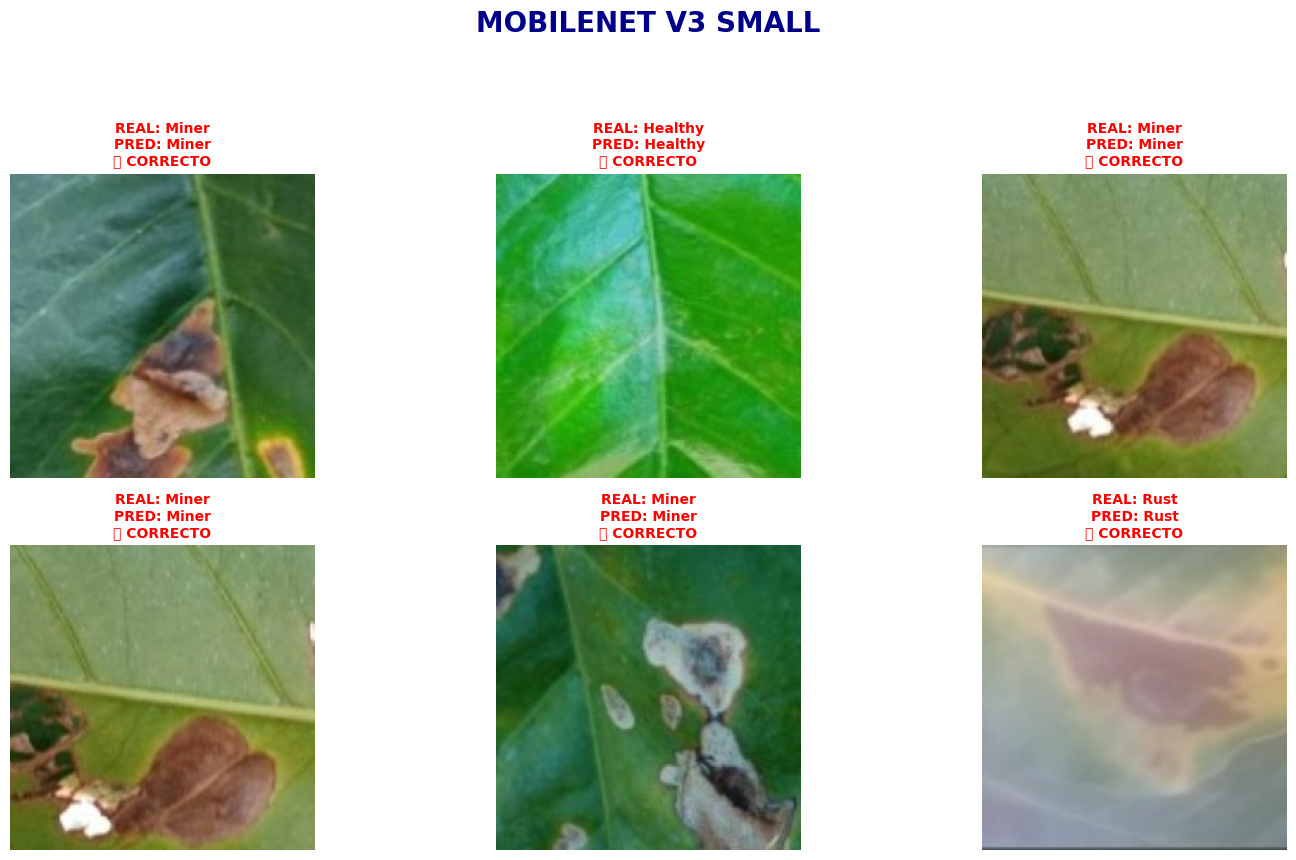

In [ ]:
#@title 🔍 Selector de Verificación Visual { run: "auto" }
#@markdown Selecciona el modelo, espera a que cargue y dale al botón "Play" si no se actualiza solo.

# 1. Parámetro del Formulario
Modelo_Elegido = "MobileNetV3-Small" #@param ["Baseline-CNN", "EfficientNet-B0", "MobileNetV3-Small"]

# 2. Lógica de selección (Asegúrate de que 'trained_m0', 'trained_m1' y 'trained_m2' existan)
if Modelo_Elegido == "Baseline-CNN":
    modelo_final = trained_m0
    titulo_grafica = "BASELINE CNN "
elif Modelo_Elegido == "EfficientNet-B0":
    modelo_final = trained_m1
    titulo_grafica = "EFFICIENTNET-B0 "
else:
    modelo_final = trained_m2
    titulo_grafica = "MOBILENET V3 SMALL"

# Imprimir en consola para verificar qué está leyendo Colab
print(f"[*] Mostrando resultados para: {titulo_grafica}")

# 3. Preparar el modelo
modelo_final.eval()
modelo_final.to(device)

# 4. Obtener lote aleatorio de imágenes reales
visual_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
inputs, labels = next(iter(visual_loader))
inputs, labels = inputs.to(device), labels.to(device)

# 5. Predicción
with torch.no_grad():
    outputs = modelo_final(inputs)
    _, preds = torch.max(outputs, 1)

# 6. Dibujar la Figura
plt.close('all') # Limpiar figuras anteriores para evitar solapamiento
fig = plt.figure(figsize=(15, 9))
fig.suptitle(titulo_grafica, fontsize=20, color='darkblue', fontweight='bold', y=0.98)

for i in range(6):
    ax = fig.add_subplot(2, 3, i+1)

    real_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    # Evaluar si es correcto para el color del título
    es_correcto = (real_label == pred_label)
    color_titulo = 'green' if es_correcto else 'red'
    icon = "✅" if es_correcto else "❌"

    texto_display = f"REAL: {real_label}\nPRED: {pred_label}\n{icon} " + ("CORRECTO" if es_correcto else "FALLO")

    # Función imshow que definimos anteriormente
    imshow(inputs.cpu().data[i], title=texto_display)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()